# LKS Setup Tutorial 

### (Note: better to run the code blocks step by step to avoid issues caused by variable redefinitions)

Here we take a look at a relatively-efficient state preparation routine introduced in [arXiv:1812.00954](https://arxiv.org/abs/1812.00954) by Guang Hao Low, Vadym Kliuchnikov, and Luke Schaeffer (hence, "LKS" state prep).

As with all state preparation techniques, the goal is the following: given a list of weights $\vec{a} = [a_0, a_1, ..., a_{2^n - 1}]$, prepare the following $n$-qubit state starting from the all-zero state (with NO garbage!):

$$ \ket{\psi} = \frac{1}{||\vec{a}||}\sum_{i = 0}^{2^n - 1}a_i\ket{i}$$

In [1]:
import numpy as np

# import QPU setups from workbench
from psiqworkbench import QPU, Qubits

# import QROM instances
from workbench_algorithms import (
    DataLookupClean,
    SwapUp,
    SelectNaive, # using full multi-control Toffoli gates for easier visualization & classical simulation
    BinaryTreeSelect, # using the optimized elbows from Babbush et al. and LKS's SELECT-SWAP trick for better quantum resource estimation
)

# import experimental Qubricks
from workbench_algorithms.experimental.subroutines import (
    MultiplexedSingleQubitRotationViaQROM,
    RotationViaPhaseGradientAddition,
    ArbitraryStatePrep,
    ProgrammableRotArray,
    FlattenedRotArray,
)

# import utility functions
from workbench_algorithms.experimental.utils import (
    StatePrepData,
    ArbitraryStatePrepData,
    get_approximated_weight_using_angle_truncation_function,
    LKS_get_b_from_epsilon,
    l2_normalize,
    SupportedOps,
    l2_norm_diff,
    generate_complex_array
)

### Example 1: 3-qubit input state with positive real amplitudes

Let's first setup a small instance where we can run the quantum circuit simulator.

We want the `ArbitraryStatePrep` circuit to create a 3-qubit state arbitrary state for us (all amplitudes are real positive):

$\ket{\psi_1} = \frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i\ket{i}$, $a_i \in \mathbb{R^+}$

In [2]:
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]
print("generated list is: ")
print(list(coeffs))
print("L2-normalized list is: ")
print(list(l2_normalize(coeffs)))

generated list is: 
[0.3745401188473625, 0.9507143064099162, 0.7319939418114051, 0.5986584841970366, 0.15601864044243652, 0.15599452033620265, 0.05808361216819946, 0.8661761457749352]
L2-normalized list is: 
[np.float64(0.22624087805797902), np.float64(0.5742787718613355), np.float64(0.4421607827705737), np.float64(0.36161952833894684), np.float64(0.0942430261295826), np.float64(0.0942284563846111), np.float64(0.03508539341033292), np.float64(0.5232135141518962)]


Oftentimes we can not create the quantum state that matches the exact input state $|\psi\rangle$, but can hope to get a quantum state $|\psi'\rangle$ that is somehow close enough to it. 

We can use a $\epsilon$ number to quantify how close we are:

$|||\psi\rangle - |\psi'\rangle|| < \epsilon$

In LKS state prep, we will implement a quantum circuit that does the following operation:

$|0^n\rangle|0\rangle_{anc} \rightarrow |\psi'\rangle|0\rangle_{anc}$

We will borrow some ancilla qubits to help with the circuit operation that is ultimately returned to the $|0\rangle$ states (thus disentangled with the preped state). Note that this is different from Alias Sampling where we have some junk/temp/garbage states that is entangled with the preped state.

Therefore, given a target $\epsilon = 0.05$, we can calculate the required precision bit `b` via the `LKS_get_b_from_epsilon()` function:

In [3]:
epsilon = 5e-2
b, _, computed_l2_diff = LKS_get_b_from_epsilon(coeffs, epsilon, return_theory_bound_and_actual_diff=True) # try mannually set b to some other number and see how it will change things!
print(b)
print(computed_l2_diff)

5
0.04855931495534788


Now let's set up the quantum circuit!

We will first create an `ArbitraryStatePrepData` object to store all the data needed.

In [4]:
data = ArbitraryStatePrepData(coeffs, bits_of_precision=b)
print(data)

ArbitraryStatePrepData(coefficients=[0.3745401188473625, 0.9507143064099162, 0.7319939418114051, 0.5986584841970366, 0.15601864044243652, 0.15599452033620265, 0.05808361216819946, 0.8661761457749352], bits_of_precision=5)


Next, we will allocate the required number of qubits for the QPU.

In [5]:
qc = QPU()
num_prep = n
num_fourier_state = b + 1
num_select_swap_anc = b + 1
num_adder_anc = b
num_qubits = num_prep + num_fourier_state + num_select_swap_anc + num_adder_anc
qc.reset(num_qubits)

Different from what you might imagine for using `AliasSampling` class, here we would need to specify more when contructing the LKS circuit since now we have a big `ArbitraryStatePrep` class that includes all the multiplexor-style state prep methods.

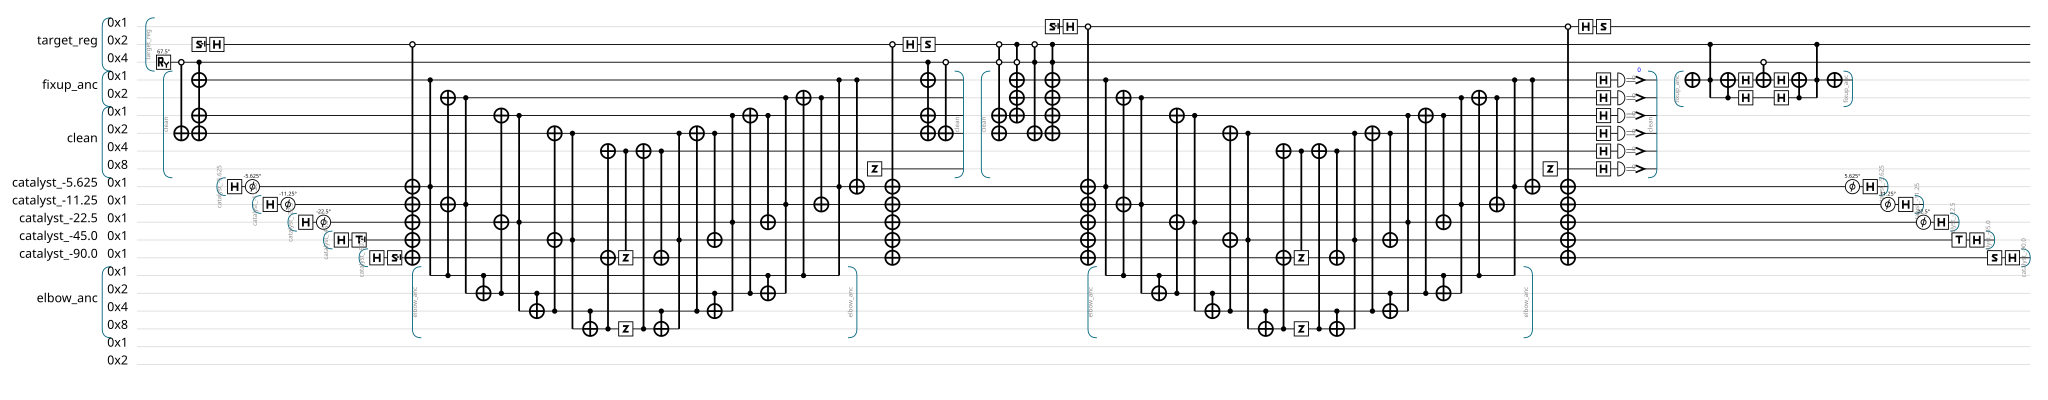

In [6]:
target_reg = Qubits(num_prep, "target_reg", qc)
qrom_instance = DataLookupClean(select=SelectNaive(), swap_up=SwapUp()) # set up the QROM, using the naive version of SELECT for simplicity
rotation_qbk_instance = RotationViaPhaseGradientAddition() # set up the phase gradient instance (see Sec D.1.2 in the Low et al. paper for details)
mplxr_instance = MultiplexedSingleQubitRotationViaQROM(qrom=qrom_instance, rotation_qbk=rotation_qbk_instance) # put both QROM and phase gradient circuit together
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance) # define the uniformly controlled rotations
state_prep = ArbitraryStatePrep(mux_rot) # finally, build the arbitrary state prep

state_prep.compute(target_reg, data)
qc.release_all_rotation_catalyst_qubits() # uncompute the Fourier states creasted by the phase gradient circuit

qc.draw()

With a small circuit instance like this, we can actually run the circuit simulator and get the preped state. We can call the `pull_state()` method to extract out the simulated quantum state for the data qubits only. 

In [7]:
preped_state = qc.pull_state()[:(1 << target_reg.num_qubits)]
cleaned_preped_state = list(np.real(preped_state))

We can compare the simulated circuit result with the classically computed approximated state by the LKS circuit and the initial input state:

In [8]:
normalized_input_coeffs = list(l2_normalize(coeffs)) # l2-normalize the initial input state
classically_computed_output_state_vec = get_approximated_weight_using_angle_truncation_function(coeffs, b) # classically compute the LKS output state

print(normalized_input_coeffs)
print(list(classically_computed_output_state_vec))
print(cleaned_preped_state)

actual_l2_diff = l2_norm_diff(cleaned_preped_state, normalized_input_coeffs) # compute the actual l2 norm difference between the circuit output and the input
print(actual_l2_diff) # this should match the computed l2 norm above

[np.float64(0.22624087805797902), np.float64(0.5742787718613355), np.float64(0.4421607827705737), np.float64(0.36161952833894684), np.float64(0.0942430261295826), np.float64(0.0942284563846111), np.float64(0.03508539341033292), np.float64(0.5232135141518962)]
[np.float64(0.224994055784104), np.float64(0.5431837009273125), np.float64(0.45448206626218496), np.float64(0.372983792593361), np.float64(0.11403760370792908), np.float64(0.11403760370792906), np.float64(0.05211057401472222), np.float64(0.5290875369675777)]
[np.float64(0.22499405578410395), np.float64(0.5431837009273125), np.float64(0.454482066262185), np.float64(0.37298379259336106), np.float64(0.11403760370792912), np.float64(0.11403760370792912), np.float64(0.05211057401472226), np.float64(0.5290875369675778)]
0.04855931495534797


### Example 2: 5-qubit input state with positive real amplitudes

In order to fully see the SELECT SWAP structure, we now create a slightly larger quantum circuit instance preping for a 5-qubit quantum state.

$\ket{\psi_2} = \frac{1}{||\vec{a}||}\sum_{i = 0}^{31}a_i\ket{i}$, $a_i \in \mathbb{R^+}$

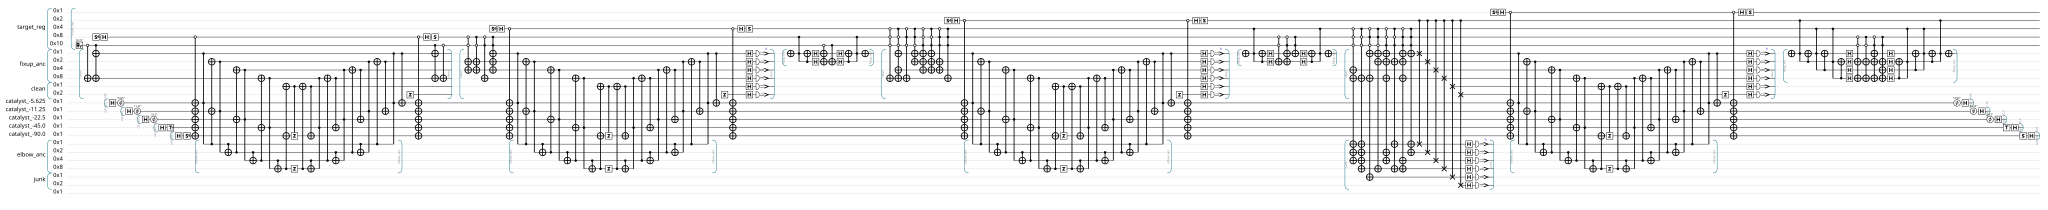

In [9]:
n = 5
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]

b = 5
data = ArbitraryStatePrepData(coeffs, bits_of_precision=b)

qc = QPU()
qc.reset(23) # need to setup additional ancilla qubits for the SELECT-SWAP

target_reg = Qubits(n, "target_reg", qc)
qrom_instance = DataLookupClean(select=SelectNaive(), swap_up=SwapUp()) # set up the QROM, using the naive version of SELECT for simplicity
rotation_qbk_instance = RotationViaPhaseGradientAddition() # set up the phase gradient instance (see Sec D.1.2 in the Low et al. paper for details)
mplxr_instance = MultiplexedSingleQubitRotationViaQROM(qrom=qrom_instance, rotation_qbk=rotation_qbk_instance) # put both QROM and phase gradient circuit together
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance) # define the uniformly controlled rotations
state_prep = ArbitraryStatePrep(mux_rot) # finally, build the arbitrary state prep

state_prep.compute(target_reg, data)
qc.release_all_rotation_catalyst_qubits() # uncompute the Fourier states creasted by the phase gradient circuit

qc.draw()

In [10]:
preped_state = qc.pull_state()[:(1 << target_reg.num_qubits)]
cleaned_preped_state = list(np.real(preped_state))

normalized_input_coeffs = list(l2_normalize(coeffs)) # l2-normalize the initial input state
classically_computed_output_state_vec = get_approximated_weight_using_angle_truncation_function(coeffs, b) # classically compute the LKS output state

print(normalized_input_coeffs)
print(list(classically_computed_output_state_vec))
print(cleaned_preped_state)

actual_l2_diff = l2_norm_diff(cleaned_preped_state, normalized_input_coeffs) # compute the actual l2 norm difference between the circuit output and the input
print(actual_l2_diff)
diff_between_theory_lks_and_circuit_output_state_vec = l2_norm_diff(classically_computed_output_state_vec, cleaned_preped_state)
print(diff_between_theory_lks_and_circuit_output_state_vec) # this value should be very close to zero

[np.float64(0.1286018161928167), np.float64(0.3264365560118694), np.float64(0.2513368945596162), np.float64(0.2055549311617348), np.float64(0.053570444155832175), np.float64(0.05356216229412405), np.float64(0.019943545804538422), np.float64(0.29740959615316), np.float64(0.20639840262999204), np.float64(0.2431232728315833), np.float64(0.007067876626935372), np.float64(0.3330275243015323), np.float64(0.28582688501497133), np.float64(0.07290859885993259), np.float64(0.062431285289258516), np.float64(0.06297363587561917), np.float64(0.10446438989655454), np.float64(0.1801799774466074), np.float64(0.14831231982241713), np.float64(0.09999622062651133), np.float64(0.21008535413050686), np.float64(0.04789650807717897), np.float64(0.1003105688871539), np.float64(0.12579372959113547), np.float64(0.1565958500302673), np.float64(0.2695974331850766), np.float64(0.06855984109440277), np.float64(0.1765671536934455), np.float64(0.2034110250437318), np.float64(0.015949179108185378), np.float64(0.208606

### Example 3: 3-qubit input state with imaginary coefficients

Now let's see another example where we want to create quantum state with complex coeffcients:

$\ket{\psi_3} = \frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i\ket{i}$, $a_i \in \mathbb{C}$

In [11]:
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = generate_complex_array(num_coeffs)
print("generated list is: ")
print(coeffs)
normalized_coeffs = l2_normalize(coeffs, allow_complex=True)
print("L2-normalized list is: ")
print(normalized_coeffs)

generated list is: 
[ 0.21004152-0.60104555j  0.27829046+0.80733389j  0.37730532+0.78424757j
 -0.91060012-0.33282174j -0.92124407+0.89915236j -0.88765667-0.68656384j
  0.97553967-0.10790964j -0.68261575-0.06343497j]
L2-normalized list is: 
[ 0.07837723-0.22428082j  0.1038444 +0.30125755j  0.1407919 +0.29264286j
 -0.33979146-0.1241928j  -0.34376326+0.33551971j -0.33123008-0.25619207j
  0.36402372-0.0402666j  -0.25471883-0.02367083j]


In [12]:
epsilon = 5e-2
b, _, computed_l2_diff = LKS_get_b_from_epsilon(coeffs, epsilon, return_theory_bound_and_actual_diff=True) # try mannually set b to some other number and see how it will change things!
print(b)
print(computed_l2_diff)

6
0.03858570450383534


Now let's pass the `coeffs` array again into the `ArbitaryStatePrepData` data object, and setup our circuit. Programming-wise it is pretty similar to the case with positive real coefficients, but there is an additional QROM at the end to load in the complex phase values.

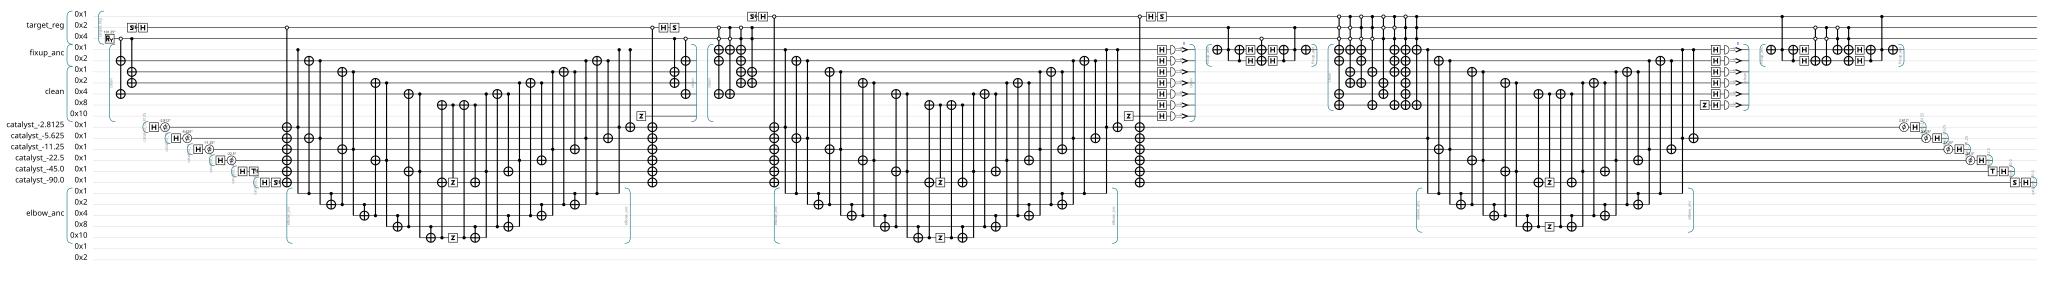

In [13]:
data = ArbitraryStatePrepData(list(coeffs), bits_of_precision=b)

qc = QPU()
qc.reset(23)

target_reg = Qubits(n, "target_reg", qc)
qrom_instance = DataLookupClean(select=SelectNaive(), swap_up=SwapUp())
rotation_qbk_instance = RotationViaPhaseGradientAddition()
mplxr_instance = MultiplexedSingleQubitRotationViaQROM(qrom=qrom_instance, rotation_qbk=rotation_qbk_instance)
amp_mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance) # define the uniformly controlled rotations for the amplitude prep
phase_mux_rot = FlattenedRotArray(mplxr_instance) # define the uniformly controlled rotations for the phase prep
state_prep = ArbitraryStatePrep(amp_mux_rot, phase_mux_rot) # finally, build the arbitrary state prep

state_prep.compute(target_reg, data)
qc.release_all_rotation_catalyst_qubits()

qc.draw()

Now let's pull out the quantum state and compare the result.

In [14]:
preped_state = qc.pull_state()[:(1 << target_reg.num_qubits)]
print(preped_state)
print(l2_norm_diff(preped_state, normalized_coeffs)) # this should match the computed l2-norm value above
diff_between_theory_lks_and_circuit_output_state_vec = l2_norm_diff(preped_state, get_approximated_weight_using_angle_truncation_function(coeffs, b))
print(diff_between_theory_lks_and_circuit_output_state_vec) # this value should be very close to zero

[ 0.06959345-0.22941885j  0.0938359 +0.30933552j  0.15524394+0.29044099j
 -0.33569808-0.1390507j  -0.336749  +0.336749j   -0.33365778-0.27382587j
  0.35536481-0.03500038j -0.23744717-0.02338651j]
0.03858570450383523
1.9957614752860253e-16


### Example 4: 3-qubit input state with a control bit

Sometimes we might wish to execute the following simplified "controlled state prep" operation:

$U_{CSP}((\alpha|0\rangle + \beta|1\rangle)|0^n\rangle) = \alpha|0\rangle|0^n\rangle + \beta|1\rangle|\psi\rangle$

rather than

$U_{SP}|0^n\rangle = |\psi\rangle$

Now we will look at a case where we want to do:

$U_{CSP}((\alpha|0\rangle + \beta|1\rangle)|0^3\rangle) = \alpha|0\rangle|0^3\rangle + \beta|1\rangle|\frac{1}{||\vec{a}||}\sum_{i = 0}^{7}a_i\ket{i}$, $a_i \in \mathbb{R^+}$

Let's do the same set up as in example 1, but now include another control register to host the control bit.

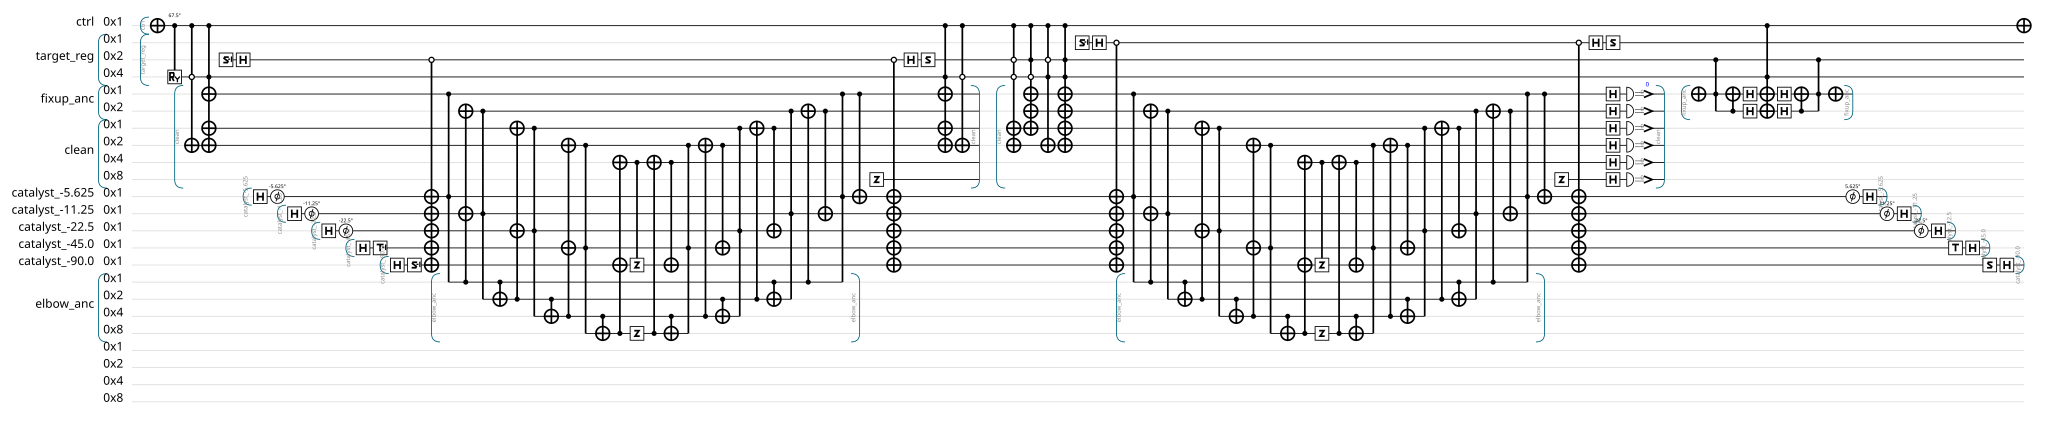

[0.22624088+0.j 0.57427877+0.j 0.44216078+0.j 0.36161953+0.j
 0.09424303+0.j 0.09422846+0.j 0.03508539+0.j 0.52321351+0.j]
[0.22499406+9.91013385e-18j 0.5431837 -4.40947213e-17j
 0.45448207-2.45768854e-17j 0.37298379-1.15148887e-17j
 0.1140376 +7.62233861e-18j 0.1140376 +1.75174984e-18j
 0.05211057+2.78538252e-19j 0.52908754-6.03096571e-17j]


In [15]:
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]

b = 5
data = ArbitraryStatePrepData(coeffs, bits_of_precision=b)

qc = QPU()
qc.reset(23)

num_ctrl = 1
ctrl_reg = Qubits(num_ctrl, "ctrl", qc) # setup control register
target_reg = Qubits(n, "target_reg", qc) # setup target register

ctrl_reg.x()

qrom_instance = DataLookupClean(select=SelectNaive(), swap_up=SwapUp())
rotation_qbk_instance = RotationViaPhaseGradientAddition()
mplxr_instance = MultiplexedSingleQubitRotationViaQROM(qrom=qrom_instance, rotation_qbk=rotation_qbk_instance)
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance) # define the uniformly controlled rotations
state_prep = ArbitraryStatePrep(mux_rot) # finally, build the arbitrary state prep

state_prep.compute(target_reg, data, ctrl_reg) # now include the control register in
qc.release_all_rotation_catalyst_qubits()

ctrl_reg.x()

qc.draw()

preped_state = qc.pull_state()[: len(coeffs) * (2 ** num_ctrl)][::(2 ** num_ctrl)] # do some hacks to skip the basis with zero values
print(l2_normalize(coeffs, allow_complex=True))
print(preped_state)

You can see that we've now added the controls on the first qubit.

### Example 5: Automatically inferring the required bits of precision

In the examples above, we've been specifying the precision for our state preparation by directly providing the number of bits of precision for the multiplexed rotations. This has a couple of disadvantages:

1. It requires users to have an in-depth understanding of the low-level implementation details for the multiplexor in order to obtain the high level properties of the state prep (i.e. a user needs to know how LKS state preparation is defined, how phase gradient addition works, what QROM is and how the number of bits of precision for it affect the overall fidelity of the state, whereas a user could simply want to prepare a state up to a desired accuracy).
2. It makes it difficult to compare like-for-like subroutines (e.g. `AliasSampling` has a deceptively similar sounding `bits_of_precision` argument, but it can't be used to directly compare against the bits of precision for LKS state prep).

The implementation of LKS state prep in the experimental WBA package offers an alternative: we can specify the 2-norm difference (the key word arg `epsilon` in `StatePrepData`) directly and infer the bits of precision required to achieve that `epsilon`:

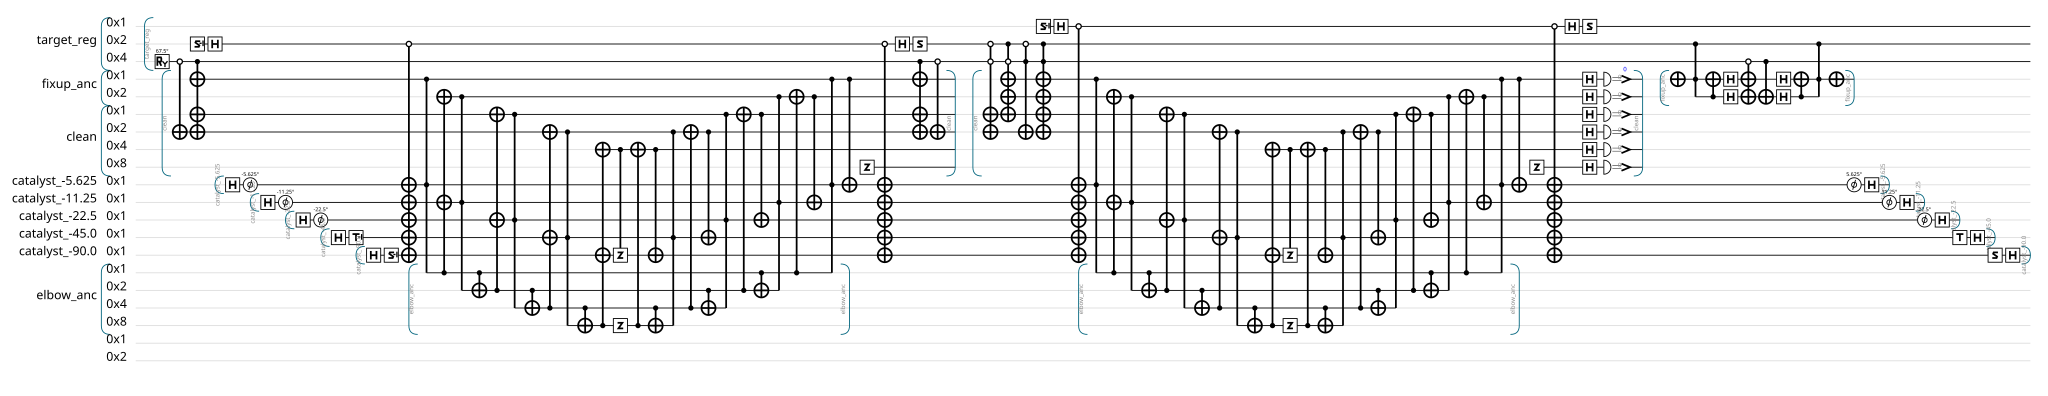

In [16]:
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]

epsilon = 5e-2
data = StatePrepData(coeffs, epsilon=epsilon)

qc = QPU()
qc.reset(20)

target_reg = Qubits(n, "target_reg", qc) # setup target register

qrom_instance = DataLookupClean(select=SelectNaive(), swap_up=SwapUp())
rotation_qbk_instance = RotationViaPhaseGradientAddition()
mplxr_instance = MultiplexedSingleQubitRotationViaQROM(qrom=qrom_instance, rotation_qbk=rotation_qbk_instance)
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance) # define the uniformly controlled rotations
state_prep = ArbitraryStatePrep(mux_rot) # finally, build the arbitrary state prep

state_prep.compute(target_reg, data) # now include the control register in
qc.release_all_rotation_catalyst_qubits()

qc.draw()